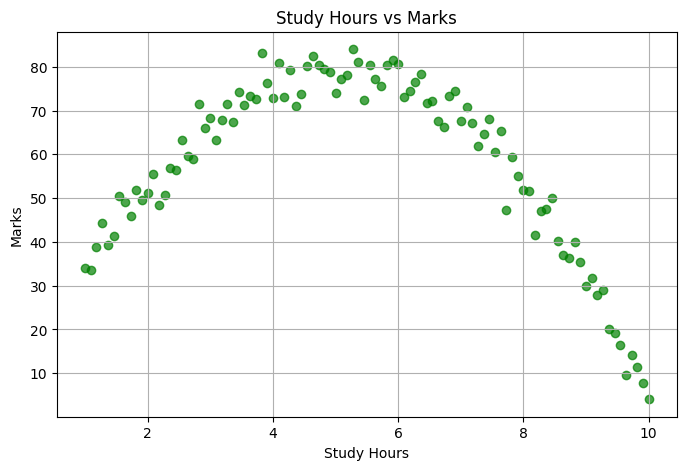

,study_hours,marks
0,1.000000,33.986857
1,1.090909,33.603968
2,1.181818,38.855217
3,1.272727,44.414433
4,1.363636,39.393965


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# set random seed
np.random.seed(42)

# generate 100 study hours between 1 and 10
study_hours = np.linspace(1, 10, 100)

# create a reverse parabola: peak at 5 hours
# Equation: marks = -a(x - h)^2 + k
a = 3
h = 5
k = 80
true_marks = -a * (study_hours - h)**2 + k

# add random noise
noise = np.random.normal(loc=0.0, scale=4, size=study_hours.shape)
marks = true_marks + noise

# create DataFrame
df = pd.DataFrame({
    "study_hours": study_hours,
    "marks": marks
})

# visualize
plt.figure(figsize=(8, 5))
plt.scatter(df["study_hours"], df["marks"], color='green', alpha=0.7)
plt.title("Study Hours vs Marks")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.grid(True)
plt.show()

# display first few rows
df.head()

In [11]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

url = 'https://raw.githubusercontent.com/kanetkar/LULML/refs/heads/main/ch09/study.csv'
df = pd.read_csv(url)
print(df.head( ))

# prepare the features (X) and target (y)
X = df[["study_hours"]]  	# feature: study hours
y = df["marks"]          		# target: marks

# split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y,
								   test_size = 0.2, random_state = 42)

# train the Linear Regression model on the training set
linear_model = LinearRegression( )
linear_model.fit(X_train, y_train)

# predict on the test set
y_pred_linear = linear_model.predict(X_test)

# evaluate the model using Mean Squared Error
mse_linear = mean_squared_error(y_test, y_pred_linear)
print(f"Linear Regression MSE (on test set): {mse_linear:.2f}")


   study_hours      marks
0     1.000000  33.986857
1     1.090909  33.603968
2     1.181818  38.855217
3     1.272727  44.414433
4     1.363636  39.393965
Linear Regression MSE (on test set): 305.47


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


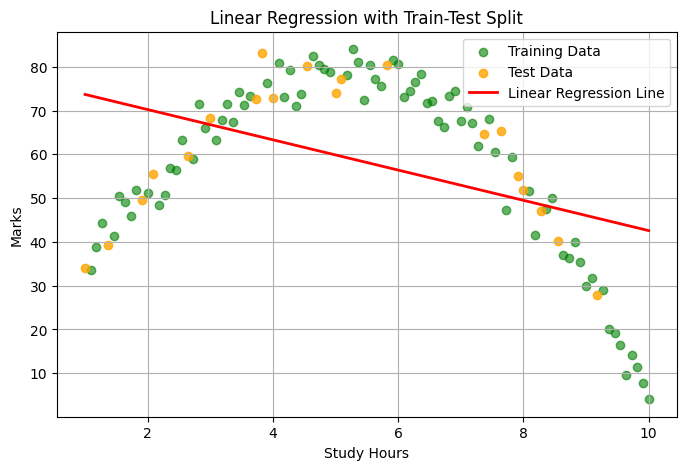

In [5]:
import matplotlib.pyplot as plt

# Plot actual training and test data
plt.figure(figsize=(8, 5))

# Plot training data
plt.scatter(X_train, y_train, color='green', label='Training Data', alpha=0.6)

# Plot test data
plt.scatter(X_test, y_test, color='orange', label='Test Data', alpha=0.8)

# Plot linear regression line (on full range for smoother curve)
# We'll use the full X range for visualization
X_full = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_full_pred_linear = linear_model.predict(X_full)

plt.plot(X_full, y_full_pred_linear, color='red', linewidth=2, label='Linear Regression Line')

plt.title("Linear Regression with Train-Test Split")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
from sklearn.preprocessing import PolynomialFeatures

# prepare the features (X) and target (y)
X = df[["study_hours"]]
y = df["marks"]

# split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y,
								   test_size = 0.2, random_state = 42)

# Step 1: Generate Polynomial Features (degree = 2)
poly = PolynomialFeatures(degree = 2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)  # Important: use transform (not fit_transform) on test set

# Step 2: Train the model on polynomial features
poly_model = LinearRegression( )
poly_model.fit(X_train_poly, y_train)

# Step 3: Predict on the test set
y_pred_poly = poly_model.predict(X_test_poly)

# Step 4: Evaluate with MSE
mse_poly = mean_squared_error(y_test, y_pred_poly)
print(f"Polynomial Regression (Degree 2) MSE (on test set): {mse_poly:.2f}")


Polynomial Regression (Degree 2) MSE (on test set): 9.91


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


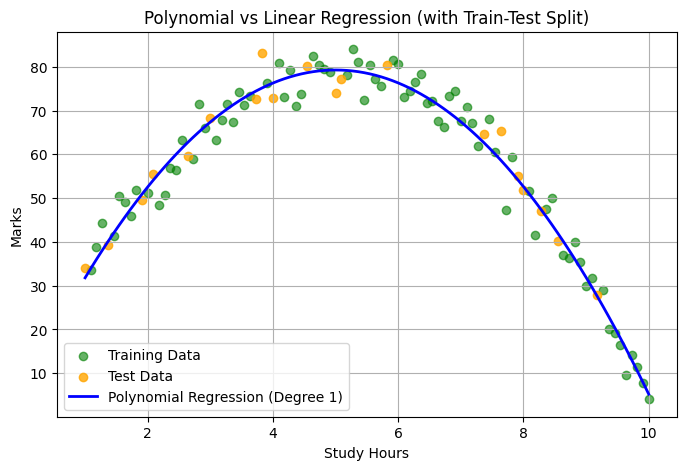

In [12]:
# generate a smooth curve for visualization using full range
X_full = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_full_poly = poly.transform(X_full)
y_full_pred_poly = poly_model.predict(X_full_poly)

# plot everything
plt.figure(figsize=(8, 5))

# training and test points
plt.scatter(X_train, y_train, color='green', label='Training Data', alpha=0.6)
plt.scatter(X_test, y_test, color='orange', label='Test Data', alpha=0.8)

# Polynomial Regression curve
plt.plot(X_full, y_full_pred_poly, color='blue', linewidth=2, label='Polynomial Regression (Degree 1)')

plt.title("Polynomial vs Linear Regression (with Train-Test Split)")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.legend()
plt.grid(True)
plt.show()

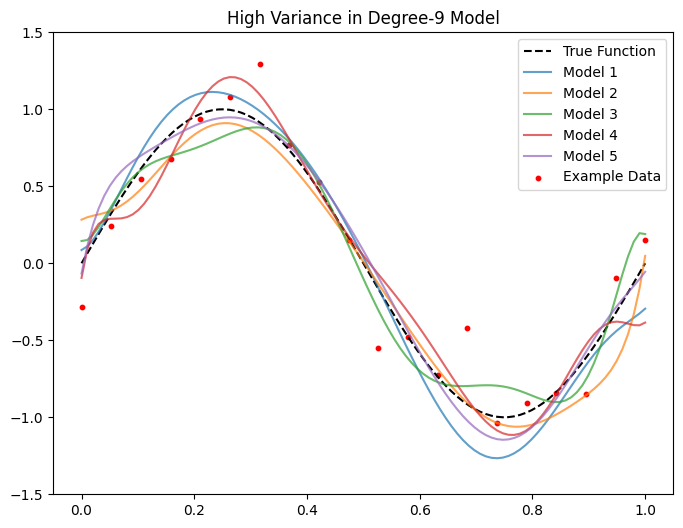

In [14]:
from sklearn.pipeline import make_pipeline

# true function
def true_function(x):
    return np.sin(2 * np.pi * x)

# generate multiple datasets with slight noise
def generate_dataset(n_samples=20, noise=0.2):
    X = np.linspace(0, 1, n_samples)
    y = true_function(X) + np.random.normal(0, noise, X.shape)
    return X.reshape(-1, 1), y

# set up
np.random.seed(42)
degree = 9
n_datasets = 5  # Number of slightly different training sets

X_test = np.linspace(0, 1, 100).reshape(-1, 1)
plt.figure(figsize=(8, 6))

# plot true function
plt.plot(X_test, true_function(X_test), 'k--', label='True Function')

# train same model on different datasets
for i in range(n_datasets):
    X_train, y_train = generate_dataset()
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    plt.plot(X_test, y_pred, alpha=0.7, label=f'Model {i+1}')

plt.scatter(*generate_dataset(), color='red', s=10, label='Example Data')
plt.ylim(-1.5, 1.5)
plt.title(f'High Variance in Degree-{degree} Model')
plt.legend()
plt.show()

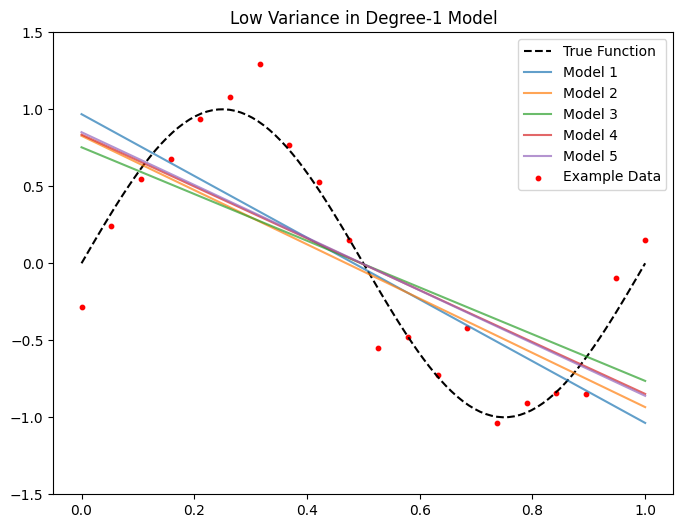

In [16]:
# True function
def true_function(x):
    return np.sin(2 * np.pi * x)

# Generate slightly different training sets
def generate_dataset(n_samples=20, noise=0.2):
    X = np.linspace(0, 1, n_samples)
    y = true_function(X) + np.random.normal(0, noise, X.shape)
    return X.reshape(-1, 1), y

# Settings
np.random.seed(42)
degree = 1  # Low complexity = low variance
n_datasets = 5  # Number of datasets

X_test = np.linspace(0, 1, 100).reshape(-1, 1)
plt.figure(figsize=(8, 6))

# Plot the true function
plt.plot(X_test, true_function(X_test), 'k--', label='True Function')

# Train on multiple datasets and plot results
for i in range(n_datasets):
    X_train, y_train = generate_dataset()
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    plt.plot(X_test, y_pred, alpha=0.7, label=f'Model {i+1}')

# Plot one sample of noisy training data
plt.scatter(*generate_dataset(), color='red', s=10, label='Example Data')
plt.ylim(-1.5, 1.5)
plt.title(f'Low Variance in Degree-{degree} Model')
plt.legend()
plt.show()

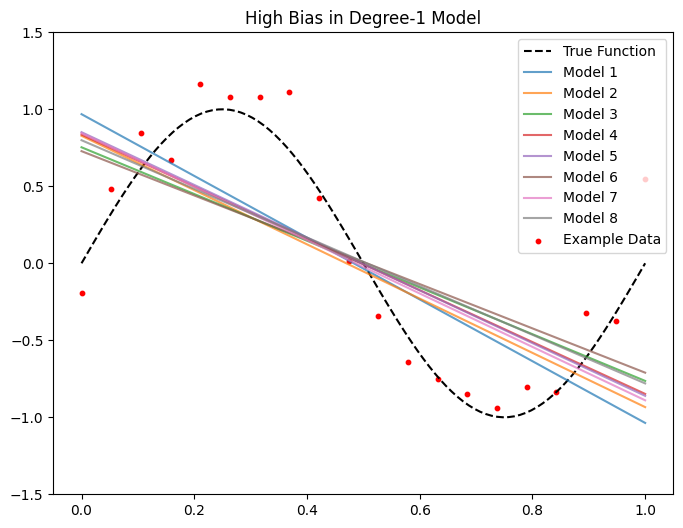

In [18]:
# true function (sinusoidal)
def true_function(x):
    return np.sin(2 * np.pi * x)

# function to generate noisy data samples
def generate_dataset(n_samples=20, noise=0.2):
    X = np.linspace(0, 1, n_samples)
    y = true_function(X) + np.random.normal(0, noise, X.shape)
    return X.reshape(-1, 1), y

# set up
np.random.seed(42)
degree = 1  # Very simple model = High bias
n_datasets = 8

X_test = np.linspace(0, 1, 100).reshape(-1, 1)
plt.figure(figsize=(8, 6))

# plot the true curve
plt.plot(X_test, true_function(X_test), 'k--', label='True Function')

# train on different datasets and plot each model
for i in range(n_datasets):
    X_train, y_train = generate_dataset()
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    plt.plot(X_test, y_pred, alpha=0.7, label=f'Model {i+1}')

# plot example training data
plt.scatter(*generate_dataset(), color='red', s=10, label='Example Data')
plt.ylim(-1.5, 1.5)
plt.title(f'High Bias in Degree-{degree} Model')
plt.legend()
plt.show()